In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [23]:
import os
print(os.getcwd())

C:\Users\Anath\2026LastSemester


In [100]:
Full_VGC = pd.read_csv("pokemon_competitive_analysis.csv")
Full_VGC

,index,name,type1,type2,ability1,ability2,hidden_ability,hp,attack,defense,...,total_stats,legendary,mythical,generation,Smogon_VGC_Usage_2022,Smogon_VGC_Usage_2023,Smogon_VGC_Usage_2024,Worlds_VGC_Usage_2022,Worlds_VGC_Usage_2023,Worlds_VGC_Usage_2024
0,1,bulbasaur,grass,poison,overgrow,No_ability,chlorophyll,45,49,49,...,318,False,False,generation-i,0.0,NoUsage,0.0,NoUsage,NoUsage,NoUsage
1,2,ivysaur,grass,poison,overgrow,No_ability,chlorophyll,60,62,63,...,405,False,False,generation-i,0.0,NoUsage,0.0,NoUsage,NoUsage,NoUsage
2,3,venusaur,grass,poison,overgrow,No_ability,chlorophyll,80,82,83,...,525,False,False,generation-i,20.83915,NoUsage,0.4441,19.62,NoUsage,0.09
3,3,venusaur-mega,grass,poison,thick-fat,No_ability,None,80,100,123,...,625,False,False,generation-i,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage
4,3,venusaur-gmax,grass,poison,overgrow,No_ability,chlorophyll,80,82,83,...,525,False,False,generation-i,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1023,iron-crown,steel,psychic,quark-drive,No_ability,None,90,72,100,...,590,False,False,generation-ix,NoUsage,NoUsage,7.84895,NoUsage,NoUsage,NoUsage
1299,1024,terapagos,normal,No_type,tera-shift,No_ability,None,90,65,85,...,450,True,False,generation-ix,NoUsage,NoUsage,11.39173,NoUsage,NoUsage,NoUsage
1300,1024,terapagos-terastal,normal,No_type,tera-shell,No_ability,None,95,95,110,...,600,True,False,generation-ix,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage
1301,1024,terapagos-stellar,normal,No_type,teraform-zero,No_ability,None,160,105,110,...,700,True,False,generation-ix,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage,NoUsage


In [204]:
keep = ['name', 'Worlds_VGC_Usage_2022', 'Worlds_VGC_Usage_2023', 'Worlds_VGC_Usage_2024']
VGC = Full_VGC[keep]
stats = ['Worlds_VGC_Usage_2022', 'Worlds_VGC_Usage_2023', 'Worlds_VGC_Usage_2024']
VGC = VGC.replace('NoUsage', 0)
VGC[stats] = VGC[stats].apply(pd.to_numeric, errors='coerce')
VGC

,name,Worlds_VGC_Usage_2022,Worlds_VGC_Usage_2023,Worlds_VGC_Usage_2024
0,bulbasaur,0.00,0.0,0.00
1,ivysaur,0.00,0.0,0.00
2,venusaur,19.62,0.0,0.09
3,venusaur-mega,0.00,0.0,0.00
4,venusaur-gmax,0.00,0.0,0.00
...,...,...,...,...
1298,iron-crown,0.00,0.0,0.00
1299,terapagos,0.00,0.0,0.00
1300,terapagos-terastal,0.00,0.0,0.00
1301,terapagos-stellar,0.00,0.0,0.00


In [210]:
keepS = ['name', 'Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']
statsS = ['Smogon_VGC_Usage_2022', 'Smogon_VGC_Usage_2023', 'Smogon_VGC_Usage_2024']
Smogon = Full_VGC[keepS]
Smogon = Smogon.replace('NoUsage', 0)
Smogon[statsS] = Smogon[statsS].apply(pd.to_numeric, errors='coerce')
Smogon


,name,Smogon_VGC_Usage_2022,Smogon_VGC_Usage_2023,Smogon_VGC_Usage_2024
0,bulbasaur,0.00000,0.0,0.00000
1,ivysaur,0.00000,0.0,0.00000
2,venusaur,20.83915,0.0,0.44410
3,venusaur-mega,0.00000,0.0,0.00000
4,venusaur-gmax,0.00000,0.0,0.00000
...,...,...,...,...
1298,iron-crown,0.00000,0.0,7.84895
1299,terapagos,0.00000,0.0,11.39173
1300,terapagos-terastal,0.00000,0.0,0.00000
1301,terapagos-stellar,0.00000,0.0,0.00000


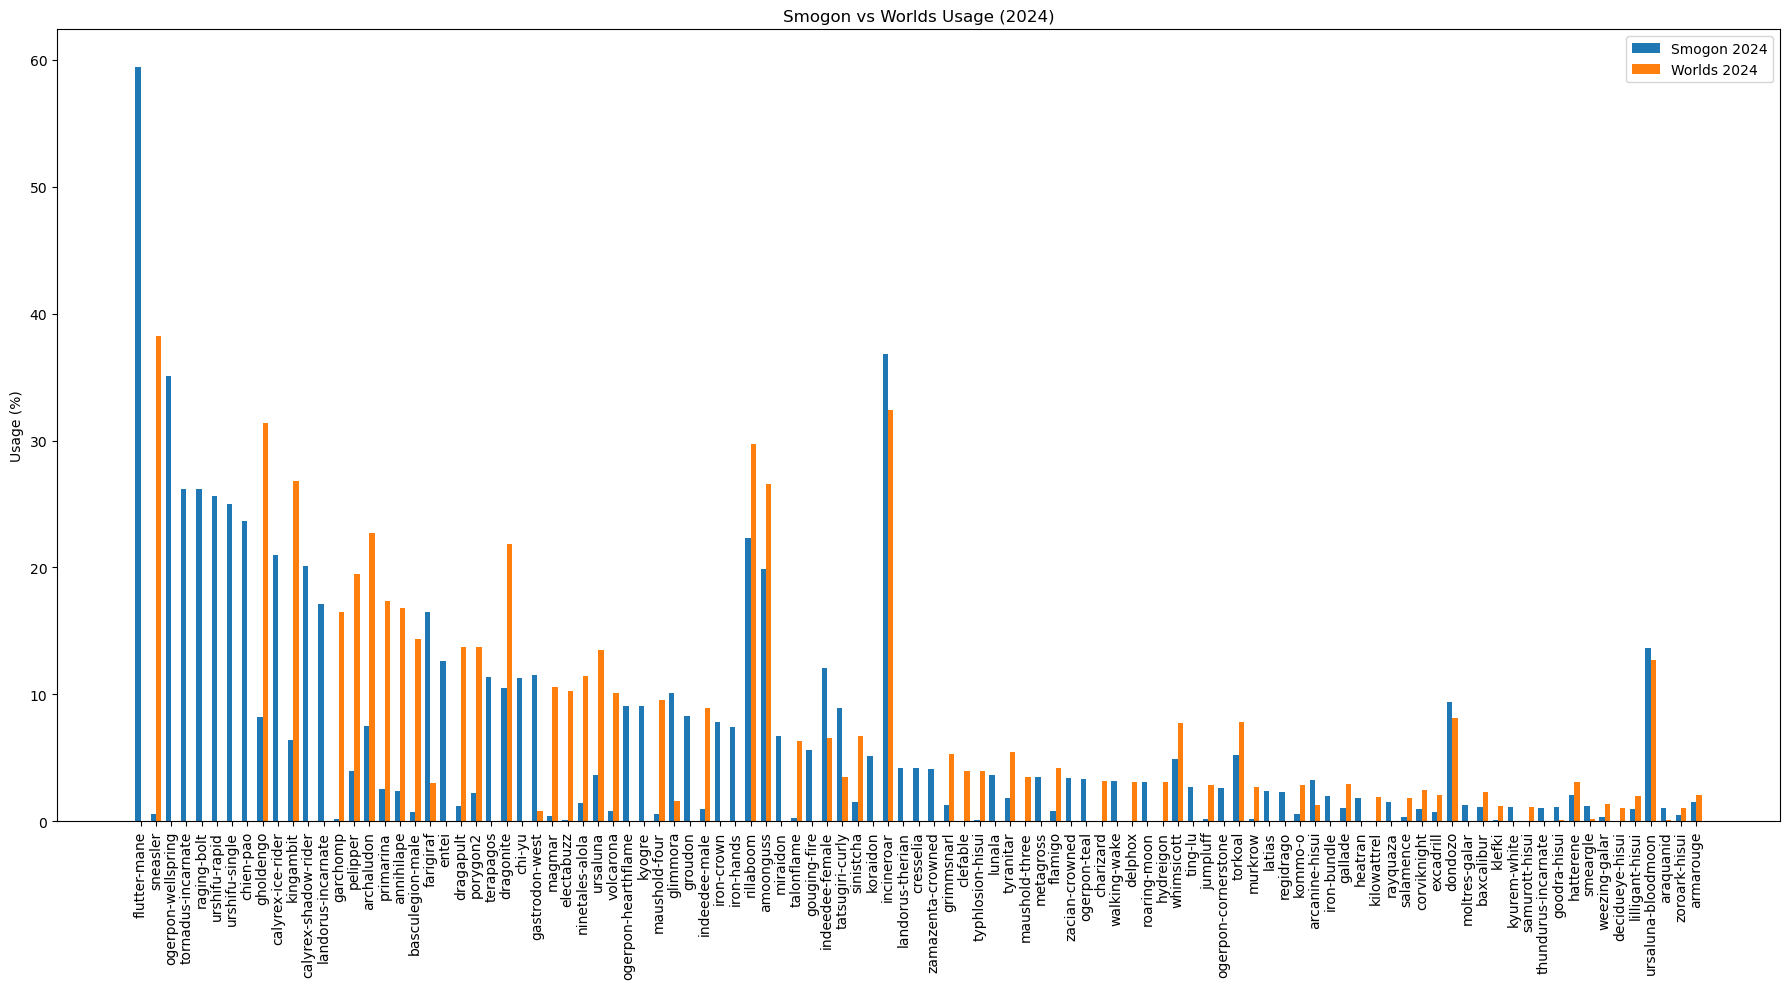

In [212]:
compare = Full_VGC[['name',
                    'Smogon_VGC_Usage_2024',
                    'Worlds_VGC_Usage_2024']].copy()

# Replace NoUsage and convert to numeric
compare = compare.replace('NoUsage', 0)
compare[['Smogon_VGC_Usage_2024',
         'Worlds_VGC_Usage_2024']] = compare[[
            'Smogon_VGC_Usage_2024',
            'Worlds_VGC_Usage_2024'
         ]].apply(pd.to_numeric, errors='coerce')

# Replace NaN with 0 for plotting
compare = compare.fillna(0)

# Optional filter: only meaningful Pokémon
compare = compare[
    (compare['Smogon_VGC_Usage_2024'] >= 1) |
    (compare['Worlds_VGC_Usage_2024'] >= 1)
]

# Sort by difference (biggest disagreements first)
compare['difference'] = abs(compare['Smogon_VGC_Usage_2024'] -
                             compare['Worlds_VGC_Usage_2024'])

compare = compare.sort_values(by='difference', ascending=False)

# Bar positions
x = np.arange(len(compare))
width = 0.35

plt.figure(figsize=(18, 10))

plt.bar(x - width/2,
        compare['Smogon_VGC_Usage_2024'],
        width,
        label='Smogon 2024')

plt.bar(x + width/2,
        compare['Worlds_VGC_Usage_2024'],
        width,
        label='Worlds 2024')

plt.xticks(x, compare['name'], rotation=90)
plt.ylabel("Usage (%)")
plt.title("Smogon vs Worlds Usage (2024)")
plt.legend()

plt.tight_layout()
plt.show()

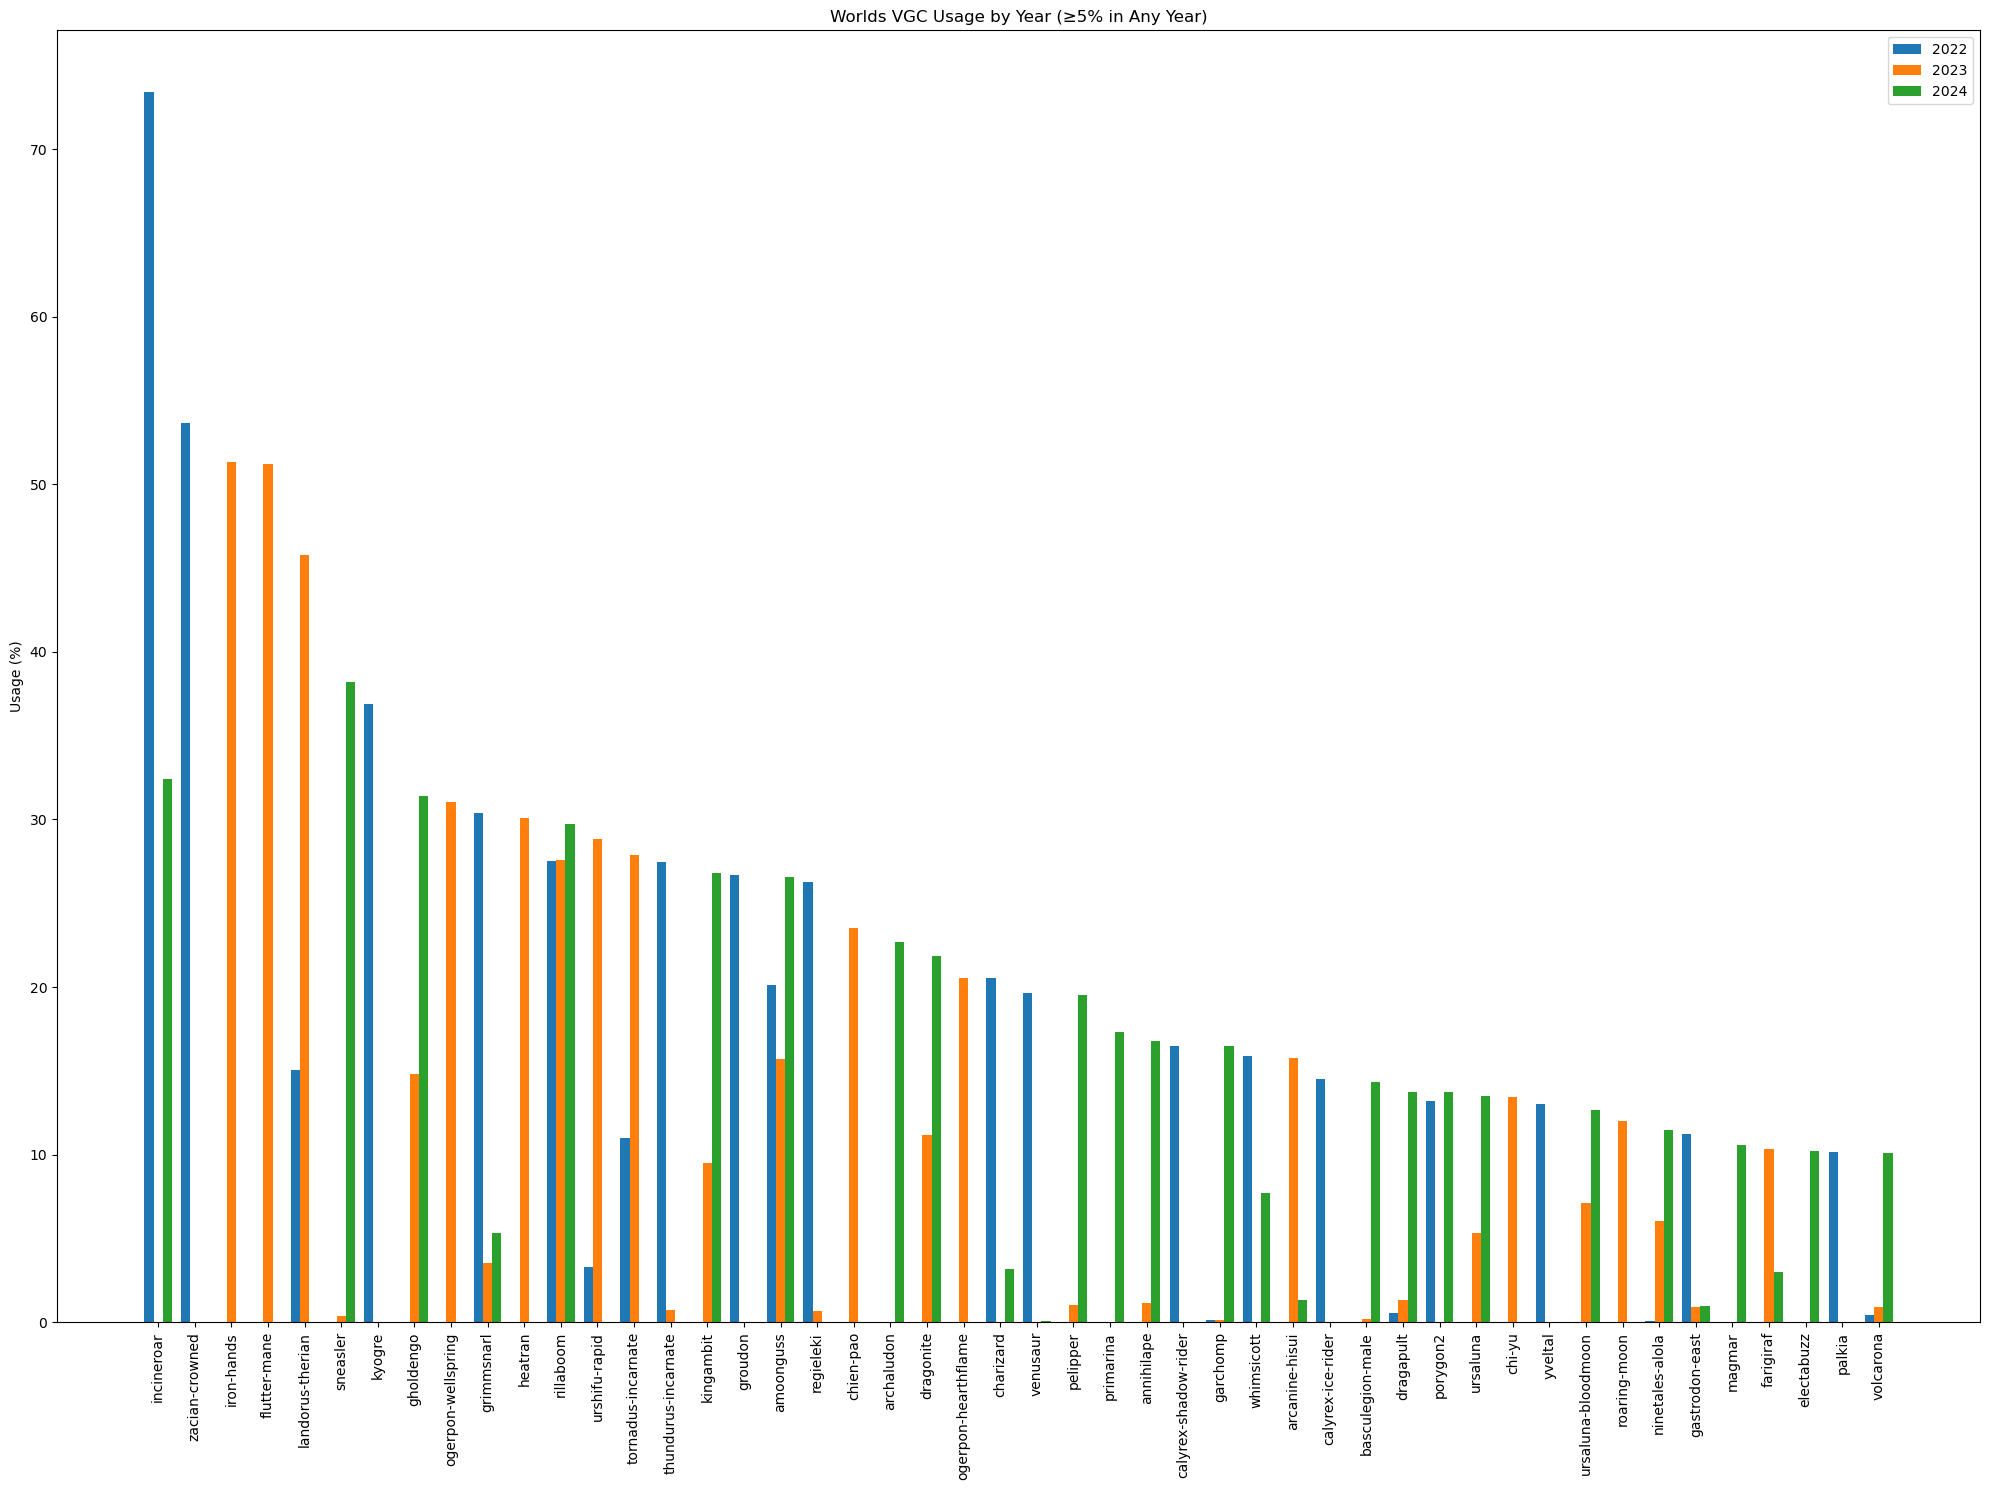

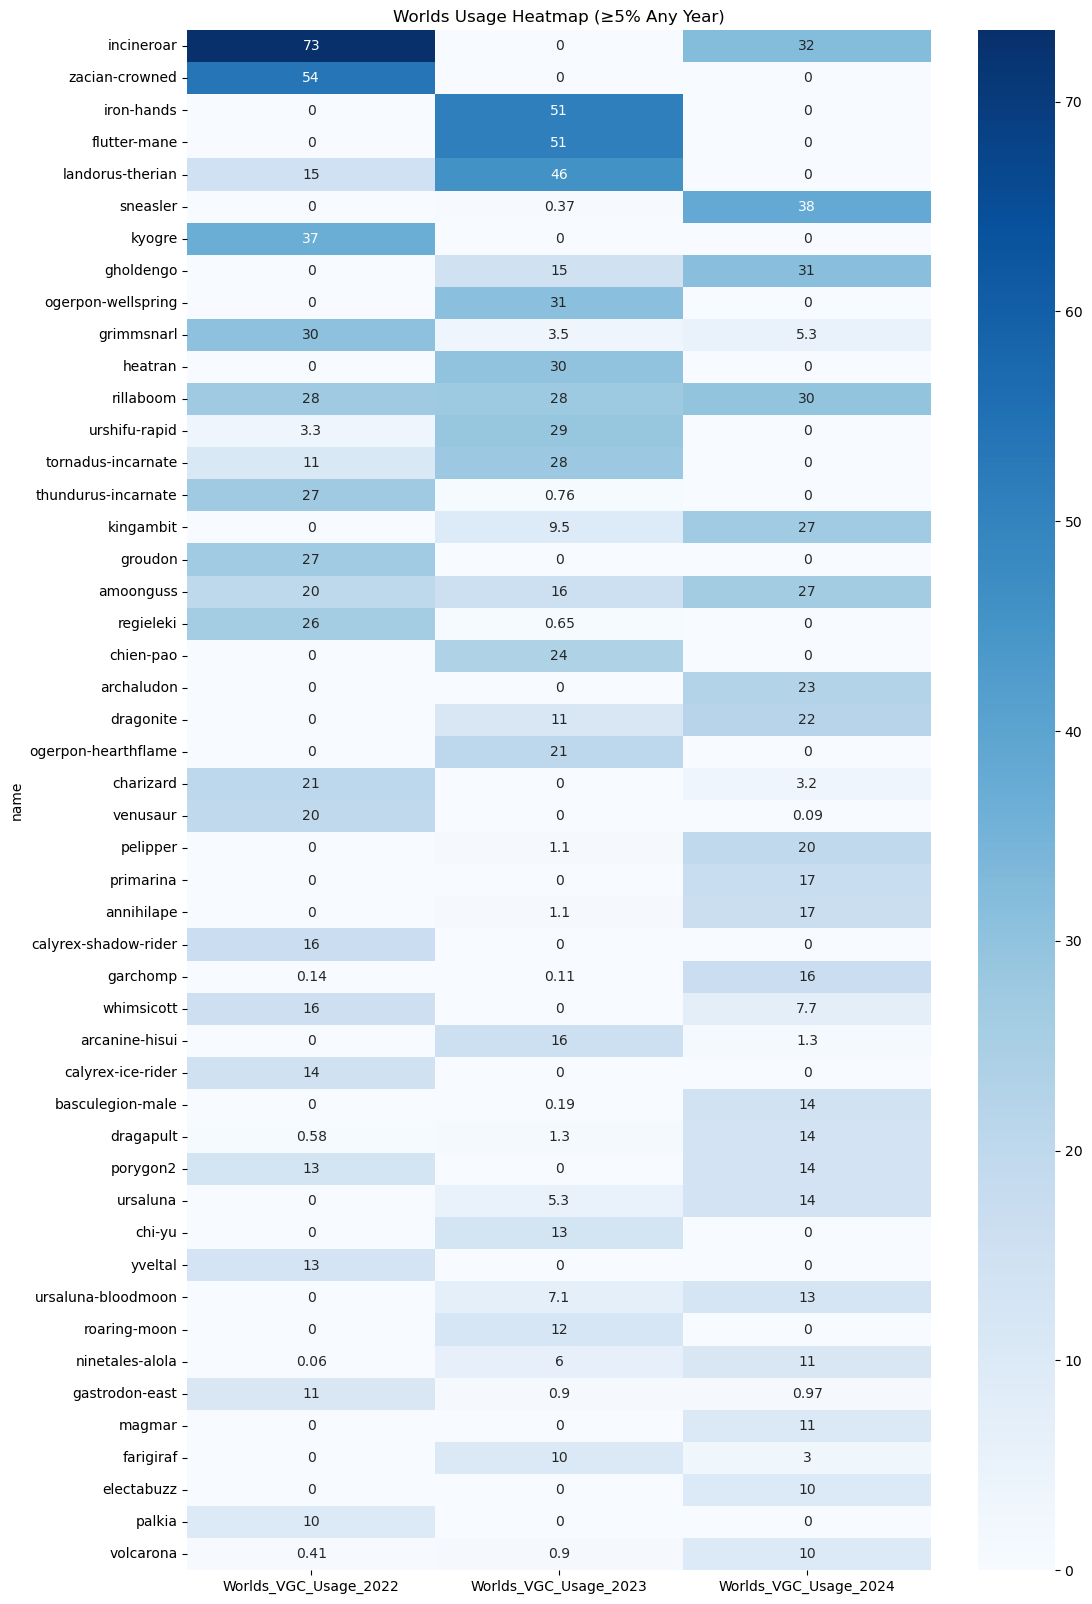

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# Make a copy so VGC remains untouched
tempVGC = VGC.copy()

# Only Worlds usage columns
usage_columns = ['Worlds_VGC_Usage_2022',
                 'Worlds_VGC_Usage_2023',
                 'Worlds_VGC_Usage_2024']

# Ensure numeric
tempVGC[usage_columns] = tempVGC[usage_columns].apply(pd.to_numeric, errors='coerce')

# 🔥 Keep Pokémon that had ≥5% in ANY of the three years
tempVGC = tempVGC[
    (tempVGC['Worlds_VGC_Usage_2022'] >= 10) |
    (tempVGC['Worlds_VGC_Usage_2023'] >= 10) |
    (tempVGC['Worlds_VGC_Usage_2024'] >= 10)
]

# Sort by highest single-year usage (optional but cleaner)
tempVGC['max_usage'] = tempVGC[usage_columns].max(axis=1)
tempVGC = tempVGC.sort_values(by='max_usage', ascending=False)

# Prepare bar positions
x = np.arange(len(tempVGC))
width = 0.25

# Create figure
plt.figure(figsize=(20, 15))

# Create grouped bars
plt.bar(x - width, tempVGC['Worlds_VGC_Usage_2022'], width, label='2022')
plt.bar(x, tempVGC['Worlds_VGC_Usage_2023'], width, label='2023')
plt.bar(x + width, tempVGC['Worlds_VGC_Usage_2024'], width, label='2024')

# Labels and formatting
plt.xticks(x, tempVGC['name'], rotation=90)
plt.ylabel('Usage (%)')
plt.title('Worlds VGC Usage by Year (≥5% in Any Year)')
plt.legend()

plt.tight_layout()
plt.show()
import seaborn as sns
# Recreate plot_data safely
usage_columns = ['Worlds_VGC_Usage_2022',
                 'Worlds_VGC_Usage_2023',
                 'Worlds_VGC_Usage_2024']

plot_data = tempVGC[usage_columns].fillna(0)

heatmap_data = plot_data.set_index(tempVGC['name'])

plt.figure(figsize=(12, 20))
sns.heatmap(heatmap_data, cmap="Blues", annot=True)
plt.title("Worlds Usage Heatmap (≥5% Any Year)")
plt.show()


In [15]:
import json
import pandas as pd

INPUT_JSON = "gen8ou.json"
OUTPUT_CSV = "gen8ou_full_matrix.csv"

with open(INPUT_JSON, "r", encoding="utf-8") as f:
    obj = json.load(f)

data = obj["data"]
total_battles = obj["info"]["number of battles"]

item_table = {}
move_table = {}
teammate_table = {}

usage_row = {}
raw_usage_row = {}
real_usage_row = {}

for mon, info in data.items():
    if not isinstance(info, dict):
        continue

    # --- usage metrics ---
    usage_row[mon] = info.get("usage", 0) or 0
    raw_usage = info.get("Raw count", 0) or 0
    raw_usage_row[mon] = raw_usage
    real_usage_row[mon] = raw_usage / total_battles if total_battles else 0

    # --- Items ---
    items = info.get("Items", {})
    if isinstance(items, dict):
        items = {k: float(v) for k, v in items.items() if k not in ("", "empty")}
        item_table[mon] = pd.Series(items, dtype="float64")
    else:
        item_table[mon] = pd.Series(dtype="float64")

    # --- Moves ---
    moves = info.get("Moves", {})
    if isinstance(moves, dict):
        moves = {k: float(v) for k, v in moves.items() if k not in ("", "empty")}
        move_table[mon] = pd.Series(moves, dtype="float64")
    else:
        move_table[mon] = pd.Series(dtype="float64")

    # --- Teammates ---
    teammates = info.get("Teammates", {})
    if isinstance(teammates, dict):
        teammates = {k: float(v) for k, v in teammates.items() if k not in ("", "empty")}
        teammate_table[mon] = pd.Series(teammates, dtype="float64")
    else:
        teammate_table[mon] = pd.Series(dtype="float64")

# Convert to DataFrames
items_df = pd.DataFrame(item_table).fillna(0)
moves_df = pd.DataFrame(move_table).fillna(0)
teammates_df = pd.DataFrame(teammate_table).fillna(0)

# Prefix to avoid collisions
items_df.index = [f"item:{i}" for i in items_df.index]
moves_df.index = [f"move:{m}" for m in moves_df.index]
teammates_df.index = [f"teammate:{t}" for t in teammates_df.index]

# Usage DataFrame
usage_df = pd.DataFrame(
    [usage_row, raw_usage_row, real_usage_row],
    index=["usage", "raw_usage", "real_usage"]
).fillna(0)

# Combine everything
final_df = pd.concat([usage_df, items_df, moves_df, teammates_df], axis=0).fillna(0)

# Ensure numeric
final_df = final_df.apply(pd.to_numeric, errors="coerce").fillna(0)

# Save
final_df.to_csv(OUTPUT_CSV)

print(f"✅ Saved: {OUTPUT_CSV}")
print(final_df.iloc[:20, :5])  # preview


✅ Saved: gen8ou_full_matrix.csv
                    Mr. Mime-Galar       Eevee    Poliwrath       Emolga  \
usage                     0.000747    0.000201     0.002568     0.000943   
raw_usage              2304.000000  680.000000  7895.000000  2951.000000   
real_usage                0.001648    0.000486     0.005646     0.002111   
item:absorbbulb           0.000000    0.000000    12.000000     2.000000   
item:adamantorb           0.000000    0.000000     0.000000     1.000000   
item:adrenalineorb        0.000000    0.000000    45.000000     0.000000   
item:aguavberry          12.000000   13.000000   256.000000    44.000000   
item:airballoon           1.000000    0.000000     8.000000     0.000000   
item:apicotberry          0.000000    0.000000     0.000000     0.000000   
item:aspearberry          0.000000    0.000000     0.000000     0.000000   
item:assaultvest          0.000000    1.000000   514.000000    63.000000   
item:babiriberry          0.000000    0.000000     0.000

In [7]:
import pandas as pd

# Load the CSV
df = pd.read_csv("gen8ou.csv")

# Display first 4 columns
print(df.iloc[:, :4])


                                           Toxicroak  \
0                                                NaN   
1  {'Moves': {'sludgebomb': 103.0, 'venoshock': 1...   

                                              Luxray  \
0                                                NaN   
1  {'Moves': {'': 13.0, 'eerieimpulse': 49.0, 'th...   

                                             Cradily  \
0                                                NaN   
1  {'Moves': {'sludgebomb': 490.0, '': 18.0, 'dig...   

                                           Heliolisk  
0                                                NaN  
1  {'Moves': {'': 21.0, 'glare': 1708.0, 'eerieim...  
